# Randomized SVD

Approximate top-$r$ singular values/vectors via random projection. From [this](https://arxiv.org/abs/0909.4061). Mixed-precision variant for tensor cores in [this paper](https://arxiv.org/abs/2304.04612).

| | SVD | RSVD |
|---|---|---|
| Cost | $O(mn^2)$ | $O(mn r)$ |
| Output | all $\min(m,n)$ singular values | top $r$ only |
| Hardware | GEMM + GEMV + sequential QR | ~95% GEMM |
| Systolic fit | poor (GEMV is 20-40x underutilized) | good |

For $r \ll \min(m,n)$, much cheaper and almost entirely GEMM.

In [1]:
import os
import sys

if "COLAB_GPU" in os.environ:
    os.system("git clone https://github.com/PritRaj1/tensor_inv.git 2>/dev/null")
    sys.path.insert(0, "/content/tensor_inv/src")
else:
    src = "src" if os.path.isdir("src") else "../src"
    sys.path.insert(0, src)

In [ ]:
import torch
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

## Algorithm

Input: $A \in \mathbb{R}^{m \times n}$, target rank $r$, oversampling $p$, power iterations $q$.

| Step | Op | Size | Hardware |
|---|---|---|---|
| 1. $Y = A \Omega$ | GEMM | $m \times n$ @ $n \times (r+p)$ | systolic |
| 2. $Q, R = \text{qr}(Y)$ | QR | $m \times (r+p)$, thin | scalar unit |
| 3. $Y = A(A^T Q)$ | 2 GEMMs | full-size | systolic |
| 4. $Q, R = \text{qr}(Y)$ | QR | thin | scalar unit |
| 5. $B = Q^T A$ | GEMM | $(r+p) \times m$ @ $m \times n$ | systolic |
| 6. $U_B, S, V^T = \text{svd}(B)$ | SVD | $(r+p) \times n$, small | scalar unit |
| 7. $U = Q U_B$ | GEMM | $m \times (r+p)$ @ $(r+p) \times r$ | systolic |

Steps 3-4 repeat $q$ times (power iteration).

### Hyperparameters

| Param | Default | Effect |
|---|---|---|
| rank $r$ | problem-dependent | how many singular values to compute |
| oversampling $p$ | 10 | extra columns for numerical stability. 5-10 is standard |
| power iterations $q$ | 1 | improves accuracy for slowly decaying spectra. 0-2 sufficient |

Cost: 4 + 2q GEMMs of size $m \times n \times (r+p)$.

In [ ]:
def rsvd_ref(A, rank, n_oversamples=10, n_power_iter=1):
    """Reference implementation."""
    r = rank + n_oversamples
    Omega = torch.randn(A.shape[1], r, dtype=A.dtype)
    Y = A @ Omega  # GEMM
    Q, _ = torch.linalg.qr(Y)
    for _ in range(n_power_iter):
        Y = A @ (A.T @ Q)  # 2 GEMMs
        Q, _ = torch.linalg.qr(Y)
        
    B = Q.T @ A  # GEMM
    Ub, S, Vt = torch.linalg.svd(B, full_matrices=False)
    U = Q @ Ub  # GEMM
    return U[:, :rank], S[:rank], Vt[:rank]

## Step by step

In [3]:
torch.manual_seed(42)
m, n, r = 200, 150, 5

# low-rank matrix + noise
A = torch.randn(m, r, dtype=torch.float64) @ torch.randn(r, n, dtype=torch.float64)
A += 0.01 * torch.randn(m, n, dtype=torch.float64)
print(f"A: {m}x{n}, target rank: {r}")

A: 200x150, target rank: 5


### 1: Random projection

In [4]:
p = 10  # oversampling
Omega = torch.randn(n, r + p, dtype=torch.float64)
Y = A @ Omega
print(f"Omega: {Omega.shape} (random Gaussian)")
print(f"Y = A @ Omega: {Y.shape}")
print(f"Y captures the column space of A in {r + p} vectors")

Omega: torch.Size([150, 15]) (random Gaussian)
Y = A @ Omega: torch.Size([200, 15])
Y captures the column space of A in 15 vectors


### 2: Orthonormalise

In [5]:
Q, _ = torch.linalg.qr(Y)
print(f"Q: {Q.shape} (orthonormal basis for column space)")
print(f"Q^T Q = I: {(Q.T @ Q - torch.eye(r + p, dtype=torch.float64)).abs().max():.1e}")

Q: torch.Size([200, 15]) (orthonormal basis for column space)
Q^T Q = I: 8.9e-16


### 3-4: Power iteration

Multiplying by $AA^T$ amplifies dominant singular values relative to small ones.

If $A = U\Sigma V^T$, then $(AA^T)^q A = U \Sigma^{2q+1} V^T$. The ratio between the $i$-th and $(i+1)$-th singular value becomes $(\sigma_i / \sigma_{i+1})^{2q+1}$, making the gap exponentially larger with each iteration.

Without power iteration, RSVD struggles when singular values decay slowly (many values of similar magnitude). With $q=1$ or $q=2$, usually sufficient.

See Section 4.3 of [the paper](https://arxiv.org/abs/0909.4061).

In [6]:
q = 1
for i in range(q):
    Y = A @ (A.T @ Q)  # 2 GEMMs
    Q, _ = torch.linalg.qr(Y)
print(f"after {q} power iteration(s): Q remains {Q.shape}")
print("power iteration suppresses noise, sharpens the subspace")

after 1 power iteration(s): Q remains torch.Size([200, 15])
power iteration suppresses noise, sharpens the subspace


### 5: Project to low-rank subspace

In [7]:
B = Q.T @ A
print(f"B = Q^T A: {B.shape} (small matrix)")

B = Q^T A: torch.Size([15, 150]) (small matrix)


### 6: SVD of small $B$

In [8]:
Ub, S, Vt = torch.linalg.svd(B, full_matrices=False)
print(f"Ub {Ub.shape}, S {S.shape}, Vt {Vt.shape}")
print(f"small matrix: only {B.shape[0]}x{B.shape[1]}, cheap")

Ub torch.Size([15, 15]), S torch.Size([15]), Vt torch.Size([15, 150])
small matrix: only 15x150, cheap


### 7: Recover full $U$ and truncate

In [9]:
U = Q @ Ub
U, S, Vt = U[:, :r], S[:r], Vt[:r]
print(f"U {U.shape}, S {S.shape}, Vt {Vt.shape}")

U torch.Size([200, 5]), S torch.Size([5]), Vt torch.Size([5, 150])


## Accuracy

In [10]:
A_approx = U @ torch.diag(S) @ Vt
_, S_ref, _ = torch.linalg.svd(A, full_matrices=False)

print(f"||A - A_r||_F / ||A||_F = {(A - A_approx).norm() / A.norm():.3e}")
print(f"optimal (Eckart-Young) = {S_ref[r:].norm() / S_ref.norm():.3e}")
print()
print(f"{'i':>4} {'rsvd':>12} {'exact':>12} {'rel diff':>12}")
print("-" * 44)
for i in range(r):
    diff = abs(S[i] - S_ref[i]) / S_ref[i]
    print(f"{i:>4} {S[i]:>12.4f} {S_ref[i]:>12.4f} {diff:>12.2e}")

||A - A_r||_F / ||A||_F = 4.208e-03
optimal (Eckart-Young) = 4.208e-03

   i         rsvd        exact     rel diff
--------------------------------------------
   0     208.0832     208.0832     2.73e-16
   1     194.8982     194.8982     2.92e-16
   2     177.5202     177.5202     1.60e-16
   3     167.8239     167.8239     8.47e-16
   4     144.9925     144.9925     5.88e-16


## Using `tensor_inv.rsvd`

All GEMMs go through `crt_matmul`.

In [11]:
from tensor_inv import rsvd

U_crt, S_crt, Vt_crt = rsvd(A, rank=r)
A_crt = U_crt @ torch.diag(S_crt) @ Vt_crt

print(f"CRT rsvd ||A - A_r|| / ||A|| = {(A - A_crt).norm() / A.norm():.3e}")
print(f"optimal (Eckart-Young)       = {S_ref[r:].norm() / S_ref.norm():.3e}")

CRT rsvd ||A - A_r|| / ||A|| = 4.208e-03
optimal (Eckart-Young)       = 4.208e-03


## Image compression

Same example as notebook 01. Randomized SVD for low-rank image approximation.

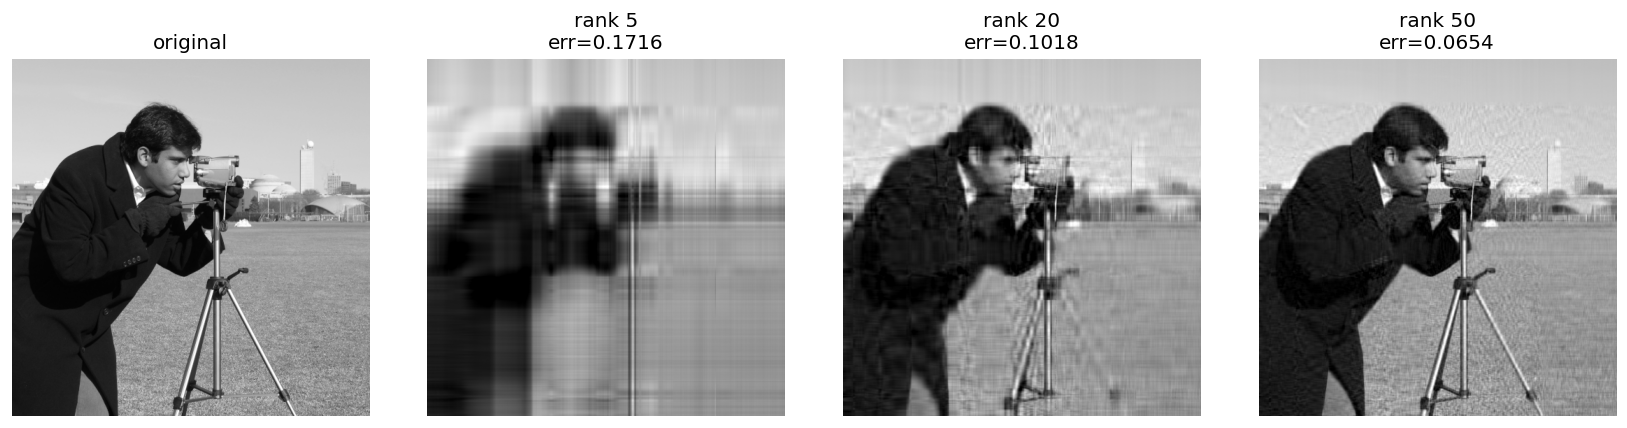

In [12]:
from skimage import data as skdata

img = torch.tensor(skdata.camera(), dtype=torch.float64) / 255.0
ranks = [5, 20, 50]
norm_A = img.norm()

fig, axes = plt.subplots(1, len(ranks) + 1, figsize=(3.5 * (len(ranks) + 1), 3.5))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("original")
axes[0].axis("off")

for ax, r in zip(axes[1:], ranks):
    U_r, S_r, Vt_r = rsvd(img, rank=r)
    recon = (U_r @ torch.diag(S_r) @ Vt_r).clamp(0, 1)
    err = (img - recon).norm() / norm_A
    ax.imshow(recon, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"rank {r}\nerr={err:.4f}")
    ax.axis("off")

plt.tight_layout()
plt.show()